### Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from tensorflow.keras.layers import Dense
from tensorflow.keras import Sequential
import keras_tuner as kt

import matplotlib.pyplot as plt
import seaborn as sns

### Data Gathering

In [2]:
df =  pd.read_csv(r"Work_from_home_burnout_dataset.csv")
df.head()

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low


### EDA & Preprocessing

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1800 non-null   int64  
 1   day_type              1800 non-null   str    
 2   work_hours            1800 non-null   float64
 3   screen_time_hours     1800 non-null   float64
 4   meetings_count        1800 non-null   int64  
 5   breaks_taken          1800 non-null   int64  
 6   after_hours_work      1800 non-null   int64  
 7   sleep_hours           1800 non-null   float64
 8   task_completion_rate  1800 non-null   float64
 9   burnout_score         1800 non-null   float64
 10  burnout_risk          1800 non-null   str    
dtypes: float64(5), int64(4), str(2)
memory usage: 154.8 KB


In [4]:
#drop unwanted columns burnout is dropped for target leakage risk
df = df.drop(labels= ['user_id','burnout_risk'], axis = 1)

### Lable + Ordinal encoding

In [5]:
df['day_type'] = df['day_type'].replace({'Weekend':0, "Weekday":1})

In [6]:
df.head()

,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score
0,1,9.59,11.86,4,2,0,7.55,91.2,19.17
1,0,7.38,10.33,4,1,0,6.69,82.0,29.70
2,0,6.31,8.92,1,2,0,8.87,80.6,32.93
3,1,8.34,10.70,4,1,1,8.13,70.0,45.47
4,0,6.97,9.83,1,2,0,5.85,67.1,51.61


### Train Test Split

In [7]:
x = df.drop( labels= "burnout_score", axis = 1)
y = df['burnout_score']
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size= 0.2, random_state= 1)
x_train.head(2)

,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate
854,1,8.55,10.30,3,2,0,7.77,82.2
1158,1,7.96,10.07,5,5,0,7.84,50.2


### Feature Scaling

In [8]:
std_scalar = StandardScaler()
x_train = pd.DataFrame(std_scalar.fit_transform(x_train), columns=x_train.columns)
x_test = pd.DataFrame(std_scalar.transform(x_test), columns=x_test.columns)

In [9]:
x_train.head(2)

,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate
0,1.032471,0.902844,0.438052,0.607789,-0.717321,-0.747289,0.736991,0.666935
1,1.032471,0.644948,0.342622,1.779431,1.395036,-0.747289,0.803661,-1.456829


### Model Training

In [15]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

In [11]:
def build_model(hp):
    model = Sequential()

    units_1 = hp.Int("units_1",min_value = 8, max_value = 32, step = 8)
    af_1 = hp.Choice("af_1", ["relu","tanh"])
    model.add(Dense(units= units_1, activation = af_1, input_dim = 8))
    
    units_2 = hp.Int("units_2",min_value = 8, max_value = 16, step = 8)
    af_2 = hp.Choice("af_2", ["relu","tanh"])
    model.add(Dense(units= units_2, activation = af_2))
    
    model.add(Dense(units= 1, activation = 'linear'))
    model.compile(loss = 'mean_squared_error', optimizer= 'adam', metrics= ['r2_score'])
    return model

tuner = kt.RandomSearch(build_model, max_trials=20, objective='val_loss', project_name = 'Regression_1')
tuner.search(x_train, y_train, epochs = 45, validation_data = (x_test,y_test), batch_size = 32, verbose = 1)

Trial 20 Complete [00h 00m 27s]
val_loss: 521.4247436523438

Best val_loss So Far: 36.94975280761719
Total elapsed time: 00h 09m 45s


In [14]:
tuner.get_best_hyperparameters(1)[0].values

{'units_1': 32, 'af_1': 'relu', 'units_2': 8, 'af_2': 'relu'}

In [17]:
#use the best hyper parameters
model = Sequential()

model.add(Dense(units= 32, activation = 'relu', input_dim = 8))
model.add(Dense(units= 8, activation = 'relu'))
model.add(Dense(units= 1, activation = 'linear')) #No activvation Fuunction
model.summary()

model.compile(loss = 'mean_squared_error', optimizer= 'adam', metrics= ['r2_score'])
history = model.fit(x_train,y_train, epochs = 45,batch_size= 32, verbose= 1, validation_data = (x_test,y_test))

C:\Velocity\Practice\2. Data_Science\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 32)                  │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 8)                   │             264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 561 (2.19 KB)

 Trainable params: 561 (2.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/45
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 2417.7173 - r2_score: -3.1280 - val_loss: 2125.2556 - val_r2_score: -3.2036
Epoch 2/45
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2210.7222 - r2_score: -2.7746 - val_loss: 1888.7542 - val_r2_score: -2.7358
Epoch 3/45
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1908.4280 - r2_score: -2.2584 - val_loss: 1547.2911 - val_r2_score: -2.0604
Epoch 4/45
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1491.2512 - r2_score: -1.5462 - val_loss: 1114.2294 - val_r2_score: -1.2038
Epoch 5/45
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1016.6747 - r2_score: -0.7359 - val_loss: 698.7284 - val_r2_score: -0.3820
Epoch 6/45
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 622.5128 - r2_score: -0.0629 - val_loss: 418.2876 - val_r2_score: 0.1727
Epoch 7/45
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 388.0027 - r2_score: 0.3375 - val_loss: 289.2185 - val_r2_score: 0.4280
Epoch 8/45
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 275.5349 - 

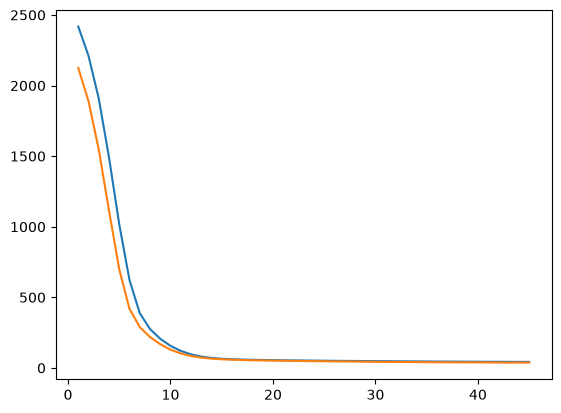

In [19]:
epochs = range(1,46)
plt.plot(epochs, history.history['loss'], label='Training Loss')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss')


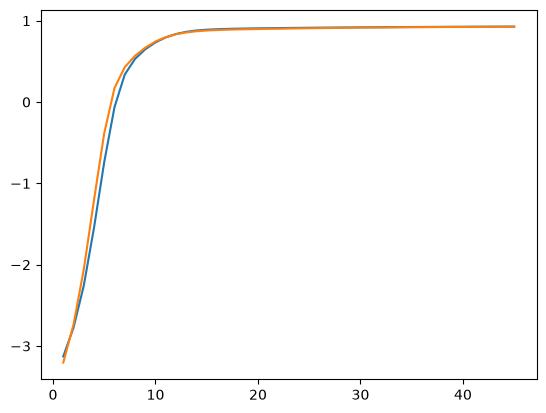

In [20]:
plt.plot(epochs,history.history['r2_score'])
plt.plot(epochs,history.history['val_r2_score'])

### Model Evaluation

In [21]:
y_pred_train = model.predict(x_train)
r2_score(y_train,y_pred_train)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


0.9280836225814265

In [22]:
y_pred_test = model.predict(x_test)
r2_score(y_test,y_pred_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


0.9250742464141578

### Save The Model

In [23]:
import pickle as pkl
import json

In [24]:
model.save('MLP_Trained_Model.keras')

In [25]:
with open('std_scalar.pkl','wb') as f:
    pkl.dump(std_scalar,f)

In [ ]:
#saving column data
col_data = {
            "day_type": {'Weekend':0, "Weekday":1},
            "colNames": list(x_train.columns)
           }

In [27]:
with open("MLP_col_data.json","w") as j:
    json.dump(col_data,j)